In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy import fft
from datetime import datetime
from scipy.stats import binned_statistic

from LSS.tabulated_cosmo import TabulatedDESI

In [2]:
%load_ext Cython

In [3]:
%%cython

import numpy as np

def cic(double[:, :, :] mesh, double[:, :] pos, double H_grid, int Nmesh):
    cdef int i, a, b, c, aa, bb, cc
    cdef double[:, :] nn = np.zeros((3, 3))
    cdef int pos_length = pos.shape[0]

    for j in range(pos_length):
        x = pos[j]
        nn = np.zeros((3, 3))
        for i in range(3):
            # Calculate the distances to neighboring grid points
            dist_1 = abs(x[i] - (H_grid * (x[i] // H_grid - 1) + 0.5 * H_grid))
            dist_2 = abs(x[i] - (H_grid * (x[i] // H_grid + 1) + 0.5 * H_grid))
            dist = abs(x[i] - (H_grid * (x[i] // H_grid) + 0.5 * H_grid))

            # Assign the weights to the neighboring grid points
            nn[i, 1] = 1 - dist / H_grid
            if dist_1 < H_grid:
                nn[i, 0] = 1 - dist_1 / H_grid
            elif dist_2 < H_grid:
                nn[i, 2] = 1 - dist_2 / H_grid

        for a in range(3):
            for b in range(3):
                for c in range(3):
                    # Calculate the indices of the cell
                    aa = int(x[0] / H_grid) + a - 1
                    bb = int(x[1] / H_grid) + b - 1
                    cc = int(x[2] / H_grid) + c - 1

                    # Apply periodic boundary conditions
                    aa = (aa + Nmesh) % Nmesh
                    bb = (bb + Nmesh) % Nmesh
                    cc = (cc + Nmesh) % Nmesh

                    # Add the weighted contribution to the mesh
                    mesh[aa, bb, cc] += nn[0, a] * nn[1, b] * nn[2, c]

    return mesh

def cic_w(double[:, :, :] mesh, double[:, :] pos, double[:] weights, double H_grid, int Nmesh):
    cdef int i, a, b, c, aa, bb, cc
    cdef double[:, :] nn = np.zeros((3, 3))
    cdef int pos_length = pos.shape[0]

    for j in range(pos_length):
        x = pos[j]
        weight = weights[j]
        nn = np.zeros((3, 3))
        for i in range(3):
            dist_1 = abs(x[i] - (H_grid * (x[i] // H_grid - 1) + 0.5 * H_grid))
            dist_2 = abs(x[i] - (H_grid * (x[i] // H_grid + 1) + 0.5 * H_grid))
            dist = abs(x[i] - (H_grid * (x[i] // H_grid) + 0.5 * H_grid))
            nn[i, 1] = 1 - dist / H_grid
            if dist_1 < H_grid:
                nn[i, 0] = 1 - dist_1 / H_grid
            elif dist_2 < H_grid:
                nn[i, 2] = 1 - dist_2 / H_grid

        for a in range(3):
            for b in range(3):
                for c in range(3):
                    aa = int(x[0] / H_grid) + a - 1
                    bb = int(x[1] / H_grid) + b - 1
                    cc = int(x[2] / H_grid) + c - 1
                    aa = (aa + Nmesh) % Nmesh
                    bb = (bb + Nmesh) % Nmesh
                    cc = (cc + Nmesh) % Nmesh
                    mesh[aa, bb, cc] += weight * nn[0, a] * nn[1, b] * nn[2, c]

    return mesh

In [4]:
def get_real_Ylm(l, m):

    # make sure l,m are integers
    l = int(l); m = int(m)

    # the relevant cartesian and spherical symbols
    x, y, z, r = sp.symbols('x y z r', real=True, positive=True)
    xhat, yhat, zhat = sp.symbols('xhat yhat zhat', real=True, positive=True)
    phi, theta = sp.symbols('phi theta')
    defs = [(sp.sin(phi), y/sp.sqrt(x**2+y**2)),
            (sp.cos(phi), x/sp.sqrt(x**2+y**2)),
            (sp.cos(theta), z/sp.sqrt(x**2+y**2+z**2))]

    # the normalization factors
    if m == 0:
        amp = sp.sqrt((2*l+1) / (4*np.pi))
    else:
        amp = sp.sqrt((2*l+1) / (2*np.pi) * sp.factorial(l-abs(m)) / sp.factorial(l+abs(m)))

    # the cos(theta) dependence encoded by the associated Legendre poly
    expr = (-1)**m * sp.assoc_legendre(l, abs(m), sp.cos(theta)) #Why additionally multiply Condon-Shortley phase?

    # the phi dependence
    if m < 0:
        expr *= sp.expand_trig(sp.sin(abs(m)*phi))
    elif m > 0:
        expr *= sp.expand_trig(sp.cos(m*phi))

    # simplify
    expr = sp.together(expr.subs(defs)).subs(x**2 + y**2 + z**2, r**2)
    expr = amp * expr.expand().subs([(x/r, xhat), (y/r, yhat), (z/r, zhat)])
    Ylm = sp.lambdify((xhat,yhat,zhat), expr, 'numexpr')

    return Ylm

In [5]:
Ylms_2 = [get_real_Ylm(2,m2) for m2 in range(-2,3)]
Ylms_4 = [get_real_Ylm(4,m4) for m4 in range(-4,5)]

In [6]:
field = 'dex-spring'

In [7]:
z_cut_l = [0.0533,0.0910,0.1825,0.2575,0.3996]   #Spring
z_cut_r = [0.0833,0.2310,0.2725,0.4675,0.4596]

#z_cut_l = [0.0521,0.1020,0.1460,0.3130,0.3757]    #Fall
#z_cut_r = [0.0821,0.2120,0.3160,0.4530,0.4757]

#z_cut_l = [0,0.101]
#z_cut_r = [0,0.211]

log_lum_cuts = [0,40.1,40.5,40.9,41.3,np.inf]

c = ['r','orange','g','b','purple']

L_x_list = [52,139,162,264,258]   #Spring
L_y_list = [218,591,691,1124,1105]
L_z_list = [106,419,303,604,268]

#L_x_list = [22,54,78,107,111]   #Fall
#L_y_list = [130,322,468,647,673]
#L_z_list = [95,317,468,373,276]

#L_x_list = [0,127]
#L_y_list = [0,541]
#L_z_list = [0,342]

In [8]:
mark = 3

In [9]:
z_min = z_cut_l[mark]
z_max = z_cut_r[mark]

log_lum_min = log_lum_cuts[mark]
log_lum_max = log_lum_cuts[mark+1]

In [10]:
print(log_lum_min,log_lum_max)

40.9 41.3


In [11]:
L_x,L_y,L_z = L_x_list[mark],L_y_list[mark],L_z_list[mark]
L_box = L_y
Nmesh = int(np.round(L_box/2.19))
H_grid = L_box/Nmesh
print(Nmesh,H_grid) #Set to 2.19Mpc/h
print('k_nyq =',np.pi/H_grid)

513 2.1910331384015596
k_nyq = 1.4338407751704305


In [12]:
file_path = '/ptmp/mpa/jmoon/hetdex_data/PDR1/V-lim/'

data = np.load(file_path+'xyz/pos_xyz_hetdex_sc2_v1.3_PDR1_oii_%s_log_lum_cut_%.1f_%.1f_z_cut_%.4f_%.4f.npy'%(field,log_lum_min,log_lum_max,z_min,z_max))

xd = data[:,0]
yd = data[:,1]
zd = data[:,2]
Noverlap_d = data[:,3]

ran = np.load(file_path+'xyz/pos_xyz_ran_dj_%s_z_cut_%.4f_%.4f.npy'%(field,z_min,z_max))

xr = ran[:,0]
yr = ran[:,1]
zr = ran[:,2]

x_shift = int(min([min(xd),min(xr)])) - 1
y_shift = int(min([min(yd),min(yr)])) - 1
z_shift = int(min([min(zd),min(zr)])) - 1
print(x_shift,y_shift,z_shift)

-212 -539 637


In [13]:
print(len(Noverlap_d))
print(len(Noverlap_d[Noverlap_d>1]))
print(len(Noverlap_d[Noverlap_d==1]))
print(len(Noverlap_d[Noverlap_d>2]))
print(len(Noverlap_d[Noverlap_d<1]))
print(len(Noverlap_d[Noverlap_d<1])/len(Noverlap_d)*100)

64794
5080
59195
518
519
0.8010000926011668


In [14]:
xd = xd[Noverlap_d>0] 
yd = yd[Noverlap_d>0] 
zd = zd[Noverlap_d>0]
Noverlap_d = Noverlap_d[Noverlap_d>0]

In [15]:
print(len(Noverlap_d))
print(len(Noverlap_d[Noverlap_d>1]))
print(len(Noverlap_d[Noverlap_d==1]))
print(len(Noverlap_d[Noverlap_d<1]))
print(len(Noverlap_d[Noverlap_d>1])/len(Noverlap_d)*100)

64275
5080
59195
0
7.903539478802022


In [16]:

my_ran = np.load(file_path+'xyz/pos_xyz_rec_ran_2000X_%d_%d_%d_%s_z_cut_%.4f_%.4f_masked.npy'%(L_x,L_y,L_z,field,z_min,z_max))

xr_m = my_ran[:,0]
yr_m = my_ran[:,1]
zr_m = my_ran[:,2]
Noverlap_r = my_ran[:,3]


In [17]:

print(len(Noverlap_r))
print(len(Noverlap_r[Noverlap_r>1]))
print(len(Noverlap_r[Noverlap_r==1]))
print(len(Noverlap_r[Noverlap_r<1]))
print(len(Noverlap_r[Noverlap_r>1])/len(Noverlap_r)*100)


4346499
173094
4173405
0
3.9823775410968687


In [18]:
xd_s,yd_s,zd_s = xd-x_shift,yd-y_shift,zd-z_shift
#xr_s,yr_s,zr_s = xr-x_shift,yr-y_shift,zr-z_shift
xr_s,yr_s,zr_s = xr_m-x_shift,yr_m-y_shift,zr_m-z_shift

In [19]:
print(np.min(xd_s),np.min(yd_s),np.min(zd_s))
print(np.min(xr_s),np.min(yr_s),np.min(zr_s))

4.34167454644853 15.128257686066263 11.279336219604147
0.609585481355623 0.07210548947500683 0.8204849210701468


In [20]:
print(np.max(xd_s),np.max(yd_s),np.max(zd_s))
print(np.max(xr_s),np.max(yr_s),np.max(zr_s))

259.2034441089385 1116.6357813946324 603.4181025825951
263.0332473449856 1122.574835634959 603.6527897357867


In [21]:
pos_dat = np.vstack((xd_s,yd_s,zd_s)).T
pos_ran = np.vstack((xr_s,yr_s,zr_s)).T

In [22]:
mesh = np.zeros((Nmesh,Nmesh,Nmesh))
mesh = cic_w(mesh,pos_dat,1/Noverlap_d,H_grid,Nmesh)
#mesh = cic(mesh,pos_dat,H_grid,Nmesh)
mesh = np.array(mesh)

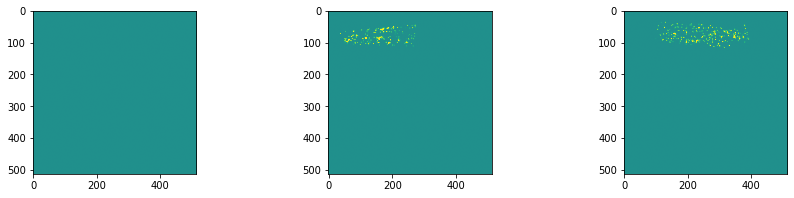

In [23]:
fig,ax = plt.subplots(1,3,figsize=(15,3))
ax[0].imshow(mesh[int(np.round(Nmesh/2))],vmin=-0.1,vmax=0.1)
ax[1].imshow(mesh[:,int(np.round(Nmesh/2)),:],vmin=-0.1,vmax=0.1)
ax[2].imshow(mesh[:,:,int(np.round(Nmesh/2))],vmin=-0.1,vmax=0.1)

In [24]:
mesh_r = np.zeros((Nmesh,Nmesh,Nmesh))
mesh_r = cic_w(mesh_r,pos_ran,1/Noverlap_r,H_grid,Nmesh)
#mesh_r = cic(mesh_r,pos_ran,H_grid,Nmesh)
mesh_r = np.array(mesh_r)

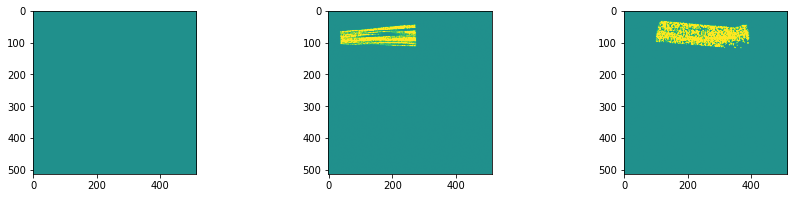

In [25]:
fig,ax = plt.subplots(1,3,figsize=(15,3))
ax[0].imshow(mesh_r[int(np.round(Nmesh/2))],vmin=-1,vmax=1)
ax[1].imshow(mesh_r[:,int(np.round(Nmesh/2)),:],vmin=-1,vmax=1)
ax[2].imshow(mesh_r[:,:,int(np.round(Nmesh/2))],vmin=-1,vmax=1)

In [26]:
alpha = np.mean(mesh_r)/np.mean(mesh)
print(alpha)
print(len(pos_ran)/len(pos_dat))

69.07334787634281
67.6234772462077


In [27]:
F_r = (mesh-mesh_r/alpha)

In [28]:
F_0 = fft.ifftn(F_r) * Nmesh**3

In [30]:
ix, iy, iz = np.mgrid[:Nmesh,:Nmesh,:Nmesh]
rx, ry, rz = H_grid*ix - L_x/2, H_grid*iy - L_y/2, H_grid*iz + z_shift #Move the observer to the center of the rectangular box & Put a box far way by z_shift
rnorm = np.sqrt(rx**2+ry**2+rz**2)
rnorm[rnorm==0.] = np.inf
rx_hat,ry_hat,rz_hat = rx/rnorm,ry/rnorm,rz/rnorm

f_1d = fft.fftfreq(Nmesh, d=H_grid)
k_1d = 2.*np.pi*f_1d

kx, ky, kz = k_1d[:,np.newaxis,np.newaxis], k_1d[np.newaxis,:,np.newaxis], k_1d[np.newaxis,np.newaxis,:]
knorm = np.sqrt(kx**2 + ky**2 + kz**2)
#fnorm = knorm / (2.*np.pi)
knorm[knorm==0.] = np.inf
kx_hat,ky_hat,kz_hat = kx/knorm,ky/knorm,kz/knorm

In [31]:
F_l_m = []

for m2 in range(5):
    F_r_Ylm = F_r*Ylms_2[m2](rx_hat,ry_hat,rz_hat)
    F_k_m = fft.fftn(F_r_Ylm)
    F_k_m *= Ylms_2[m2](kx_hat,ky_hat,kz_hat)
    F_l_m.append(F_k_m)
F_l_2 = np.sum(F_l_m,axis=0)
F_l_2 *= (4*np.pi)

In [32]:
F_l_m = []

for m4 in range(9):
    F_r_Ylm = F_r*Ylms_4[m4](rx_hat,ry_hat,rz_hat)
    F_k_m = fft.fftn(F_r_Ylm)
    F_k_m *= Ylms_4[m4](kx_hat,ky_hat,kz_hat)
    F_l_m.append(F_k_m)
F_l_4 = np.sum(F_l_m,axis=0)
F_l_4 *= (4*np.pi)

In [27]:
norm = np.sum(mesh*mesh_r)/H_grid**3/alpha
print(norm)

103.40639477374336


In [28]:
P_shot = (np.sum((1/Noverlap_d)**2)+1/alpha**2*(np.sum((1/Noverlap_r)**2)))/norm
print(P_shot)

592.549040183009


In [ ]:
P_shot = (np.mean(mesh)*Nmesh**3 + 1/alpha**2*(np.mean(mesh_r)*Nmesh**3)) / norm

In [34]:
P0_3d = np.abs(F_0)**2/norm
P2_3d = (F_l_2*F_0).real/norm
P4_3d = (F_l_4*F_0).real/norm

In [35]:
k_s = 2*np.pi / H_grid
Wk2 = np.sinc(kx/k_s)*np.sinc(ky/k_s)*np.sinc(kz/k_s)

C_cic = (1-(2/3)*np.sin(H_grid/2.*kx)**2)*(1-(2/3)*np.sin(H_grid/2.*ky)**2)*(1-(2/3)*np.sin(H_grid/2.*kz)**2)

In [36]:
P_shot = (np.sum((1/Noverlap_d)**2)+1/alpha**2*(np.sum((1/Noverlap_r)**2)))/norm
#P_shot = (np.mean(mesh)*Nmesh**3 + 1/alpha**2*(np.sum((1/Noverlap_r)**2))) / norm
#P_shot = (np.mean(mesh)*Nmesh**3 + 1/alpha**2*(np.mean(mesh_r)*Nmesh**3)) / norm
#P_shot = (np.sum((1/Noverlap_d)**2) + 1/alpha**2*(np.mean(mesh_r)*Nmesh**3)) / norm
print(P_shot)
P_shot_cic = P_shot * C_cic

301.5325505335315


In [37]:
P0_3d_deconv = (P0_3d-P_shot_cic)/Wk2**4
P2_3d_deconv = P2_3d/Wk2**4
P4_3d_deconv = P4_3d/Wk2**4

In [38]:
mu = np.linspace(0,1,5)
mu = np.append(mu,[0.8,0.85,0.9,0.95])
mu.sort()
print(mu)

[0.   0.25 0.5  0.75 0.8  0.85 0.9  0.95 1.  ]


In [39]:
L_2,L_4 = np.ones(len(mu)-1),np.ones(len(mu)-1)

for n_mu in range(len(mu)-1):
    L_2[n_mu] = 0.5*(mu[n_mu+1]**3 - mu[n_mu+1] - mu[n_mu]**3 + mu[n_mu])/(mu[n_mu+1]-mu[n_mu])
    L_4[n_mu] = (1/8)*(7*(mu[n_mu+1]**5-mu[n_mu]**5)-10*(mu[n_mu+1]**3-mu[n_mu]**3)+3*(mu[n_mu+1]-mu[n_mu]))/(mu[n_mu+1]-mu[n_mu])

In [40]:
P_kmu_3d = []

for n_mu in range(len(mu)-1):
    P_kmu_3d.append(P0_3d + P2_3d*L_2[n_mu] + P4_3d*L_4[n_mu])

In [41]:
P_kmu_3d_deconv = []
for n_mu in range(len(mu)-1):
    P_kmu_3d_deconv.append((P_kmu_3d[n_mu]-P_shot_cic)/Wk2**4)

In [42]:
ks = 2*np.pi / L_box * np.arange(0.5,Nmesh+.5)

knorm_flat = np.sqrt(kx**2 + ky**2 + kz**2).ravel()
kbin, bin_edges, bin_number = binned_statistic(knorm_flat, knorm_flat, bins=ks, statistic="mean")

P0_1d_deconv, bin_edges, bin_number = binned_statistic(knorm_flat, P0_3d_deconv.ravel(), bins=ks, statistic="mean")
P2_1d_deconv, bin_edges, bin_number = binned_statistic(knorm_flat, P2_3d_deconv.ravel(), bins=ks, statistic="mean")
P4_1d_deconv, bin_edges, bin_number = binned_statistic(knorm_flat, P4_3d_deconv.ravel(), bins=ks, statistic="mean")

P_kmu_1d_deconv = []
for n_mu in range(len(mu)-1):
    P_kmu_1d, bin_edges, bin_number = binned_statistic(knorm_flat, P_kmu_3d_deconv[n_mu].ravel(), bins=ks, statistic="mean")
    P_kmu_1d_deconv.append(P_kmu_1d)

In [43]:
#np.savetxt('results/PDR1/pk_multipoles_my_code_oii_PDR1_%s_log_lum_cut_%.1f_%.1f_z_cut_%.4f_%.4f_L_box_%d_Nmesh_%d_cic_my_ran.txt'%(field,log_lum_min,log_lum_max,z_min,z_max,L_box,Nmesh),np.vstack((kbin,P0_1d_deconv,P2_1d_deconv,P4_1d_deconv)).T)
#for n_mu in range(len(mu)-1):
#    np.savetxt('results/PDR1/pkmu_my_code_oii_PDR1_%s_log_lum_cut_%.1f_%.1f_z_cut_%.4f_%.4f_L_box_%d_Nmesh_%d_cic_my_ran_alpha_%dX_wd+wr+cen+z_shift_mu_%.2f_%.2f.txt'%(field,log_lum_min,log_lum_max,z_min,z_max,L_box,Nmesh,alpha,mu[n_mu],mu[n_mu+1]),np.vstack((kbin,P_kmu_1d_deconv[n_mu])).T)

Text(0.5, 1.0, 'P4')

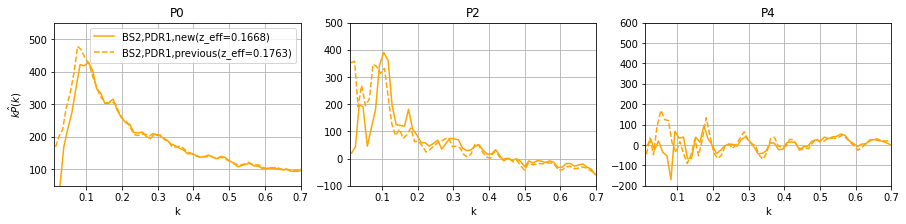

In [44]:
fig,ax = plt.subplots(1,3,figsize=(15,3))

ax[0].plot(kbin,kbin*(P0_1d_deconv),c=c[mark],label='BS2,PDR1,new(z_eff=0.1668)')
ax[1].plot(kbin,kbin*(P2_1d_deconv),c=c[mark])
ax[2].plot(kbin,kbin*(P4_1d_deconv),c=c[mark])

data = np.loadtxt('results/PDR1/pk_multipoles_my_code_oii_PDR1_dex-spring_log_lum_cut_40.1_40.5_z_cut_0.0910_0.2310_L_box_591_Nmesh_270_cic_my_ran.txt')
k_d = data[:,0]
P0_d = data[:,1]
P2_d = data[:,2]
P4_d = data[:,3]

ax[0].plot(k_d,k_d*P0_d,c=c[mark],label='BS2,PDR1,previous(z_eff=0.1763)',ls='--')
ax[1].plot(k_d,k_d*P2_d,c=c[mark],ls='--')
ax[2].plot(k_d,k_d*P4_d,c=c[mark],ls='--')

ax[0].set_ylabel(r'$k\hat{P}(k)$')

for i in range(3):
    ax[i].set_xlabel(r'k')
    ax[i].set_xlim(0.01,0.7)
    ax[i].grid()
ax[0].legend()

ax[0].set_ylim(50,550)
ax[1].set_ylim(-100,500)
ax[2].set_ylim(-200,600)
ax[0].set_title('P0')
ax[1].set_title('P2')
ax[2].set_title('P4')

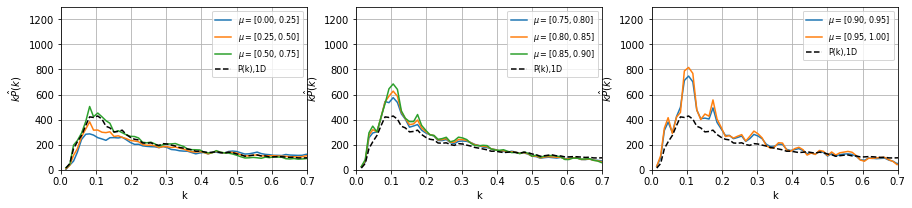

In [45]:
fig,ax = plt.subplots(1,3,figsize=(15,3))

for n_mu in range(3):
    ax[0].plot(kbin,kbin*(P_kmu_1d_deconv[n_mu]),label=r'$\mu=[%.2f,%.2f]$'%(mu[n_mu],mu[n_mu+1]))
    
for n_mu in range(3,6):
    ax[1].plot(kbin,kbin*(P_kmu_1d_deconv[n_mu]),label=r'$\mu=[%.2f,%.2f]$'%(mu[n_mu],mu[n_mu+1]))
    
for n_mu in range(6,len(mu)-1):
    ax[2].plot(kbin,kbin*(P_kmu_1d_deconv[n_mu]),label=r'$\mu=[%.2f,%.2f]$'%(mu[n_mu],mu[n_mu+1]))

for i in range(3):
    ax[i].plot(kbin,kbin*(P0_1d_deconv),label='P(k),1D',c='k',ls='--')
    ax[i].set_ylim(0,1300)
    ax[i].set_ylabel('$k\hat{P}(k)$')
    ax[i].set_xlabel(r'k')
    ax[i].set_xlim(0.,0.7)
    ax[i].grid()
    ax[i].legend(prop={'size':8})

Text(0.5, 1.0, 'P4')

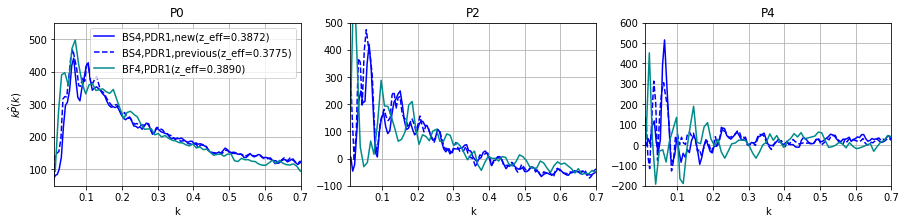

In [46]:
fig,ax = plt.subplots(1,3,figsize=(15,3))

data = np.loadtxt('results/PDR1/pk_multipoles_my_code_oii_PDR1_dex-spring_log_lum_cut_40.9_41.3_z_cut_0.2575_0.4675_L_box_1124_Nmesh_513_cic_my_ran.txt')
k_d = data[:,0]
P0_d = data[:,1]
P2_d = data[:,2]
P4_d = data[:,3]

ax[0].plot(k_d,k_d*P0_d,c='b',label='BS2,PDR1,(z_eff=)',ls='--')
ax[1].plot(k_d,k_d*P2_d,c='b',ls='--')
ax[2].plot(k_d,k_d*P4_d,c='b',ls='--')

data = np.loadtxt('results/PDR1/pk_multipoles_my_code_oii_PDR1_dex-fall_log_lum_cut_40.9_41.3_z_cut_0.3130_0.4530_L_box_647_Nmesh_295_cic_my_ran.txt')
k_d = data[:,0]
P0_d = data[:,1]
P2_d = data[:,2]
P4_d = data[:,3]

ax[0].plot(k_d,k_d*P0_d,c='darkcyan',label='BF2,PDR1(z_eff=0.3890)')
ax[1].plot(k_d,k_d*P2_d,c='darkcyan')
ax[2].plot(k_d,k_d*P4_d,c='darkcyan')

ax[0].set_ylabel(r'$k\hat{P}(k)$')

for i in range(3):
    ax[i].set_xlabel(r'k')
    ax[i].set_xlim(0.01,0.7)
    ax[i].grid()
ax[0].legend()

ax[0].set_ylim(50,550)
ax[1].set_ylim(-100,500)
ax[2].set_ylim(-200,600)
ax[0].set_title('P0')
ax[1].set_title('P2')
ax[2].set_title('P4')